# Data Preparation



In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Normalization
Based off dynamic limit for later steps of quatization to Q4.4 (0, 15.9375) fixed point.


In [29]:
MAX_PREASSURE_LIMIT = 250 # mmHG

# Load the dataset
df = pd.read_csv("DatosEntrenamiento.csv")

# Separate data and labels
labels = df["POSICION"].values
data = df.drop(columns=["POSICION"]).values

# Find the max value for normalization
data_min = data.min()
data_max = data.max()
print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Data range: [{data_min.min():.4f}, {data_max.max():.4f}]")
print(f"Labels: {np.unique(labels)}")

# Normalize to Q4.4 range
# Lets choose a fix max value based on our dataset (~236mmHg)
scale_factor = 15.9375 / MAX_PREASSURE_LIMIT
data_normalized = data * scale_factor
print(f"Normalized range: [{data_normalized.min():.4f}, {data_normalized.max():.4f}]")

Data shape: (192, 64)
Data type: float64
Data range: [0.0000, 213.4010]
Labels: ['fetus_L' 'fetus_R' 'prone' 'supine' 'trunk_L' 'trunk_R']
Normalized range: [0.0000, 13.6043]


## Quantization

Convert normalized float data to Q4.4 unsigned fixed-point (4 bits integer + 4 bits fractional = 8 bits total).

In [30]:
# Quantize the normalized data
data_clipped = np.clip(data_normalized, 0, 15.9375)
data_q44 = np.round(data_clipped * 16).astype(np.uint8)

print(f"Q4.4 shape: {data_q44.shape}")
print(f"Q4.4 type: {data_q44.dtype}")
print(f"Q4.4 range: [{data_q44.min()}, {data_q44.max()}]")

Q4.4 shape: (192, 64)
Q4.4 type: uint8
Q4.4 range: [0, 218]


### Quantization Error Analysis

For uniform quantization with rounding, the maximum error is:
$$\epsilon_{max} = \pm \frac{1}{2} \text{ LSB} = \pm \frac{\Delta}{2}$$
Where:
- Δ (LSB) = $2^{-f}$ = step size = $2^{-4} = \frac{1}{16} = 0.0625$
- f = number of fractional bits = 4 (for Q4.4)
Therefore:
$$\epsilon_{max} = \pm \frac{0.0625}{2} = \pm 0.03125 = \pm \frac{1}{32}$$
Or in Q4.4 terms: ±0.5 LSB = ±2⁻⁵

In [31]:
# Quantization Error Analysis
dequantized = data_q44.astype(np.float32) / 16.0
abs_error = np.abs(data_normalized - dequantized)

print(f"Theoretical max error (±0.5 LSB): ±{0.03125:.5f}")
print(f"Actual max error: {np.max(abs_error):.5f}")
print(f"Mean absolute error: {np.mean(abs_error):.5f}")
print(f"RMSE: {np.sqrt(np.mean(abs_error**2)):.5f}")
print(f"Errors within bound: {np.all(abs_error <= 0.03125 + 1e-6)}")

Theoretical max error (±0.5 LSB): ±0.03125
Actual max error: 0.03125
Mean absolute error: 0.01384
RMSE: 0.01692
Errors within bound: True


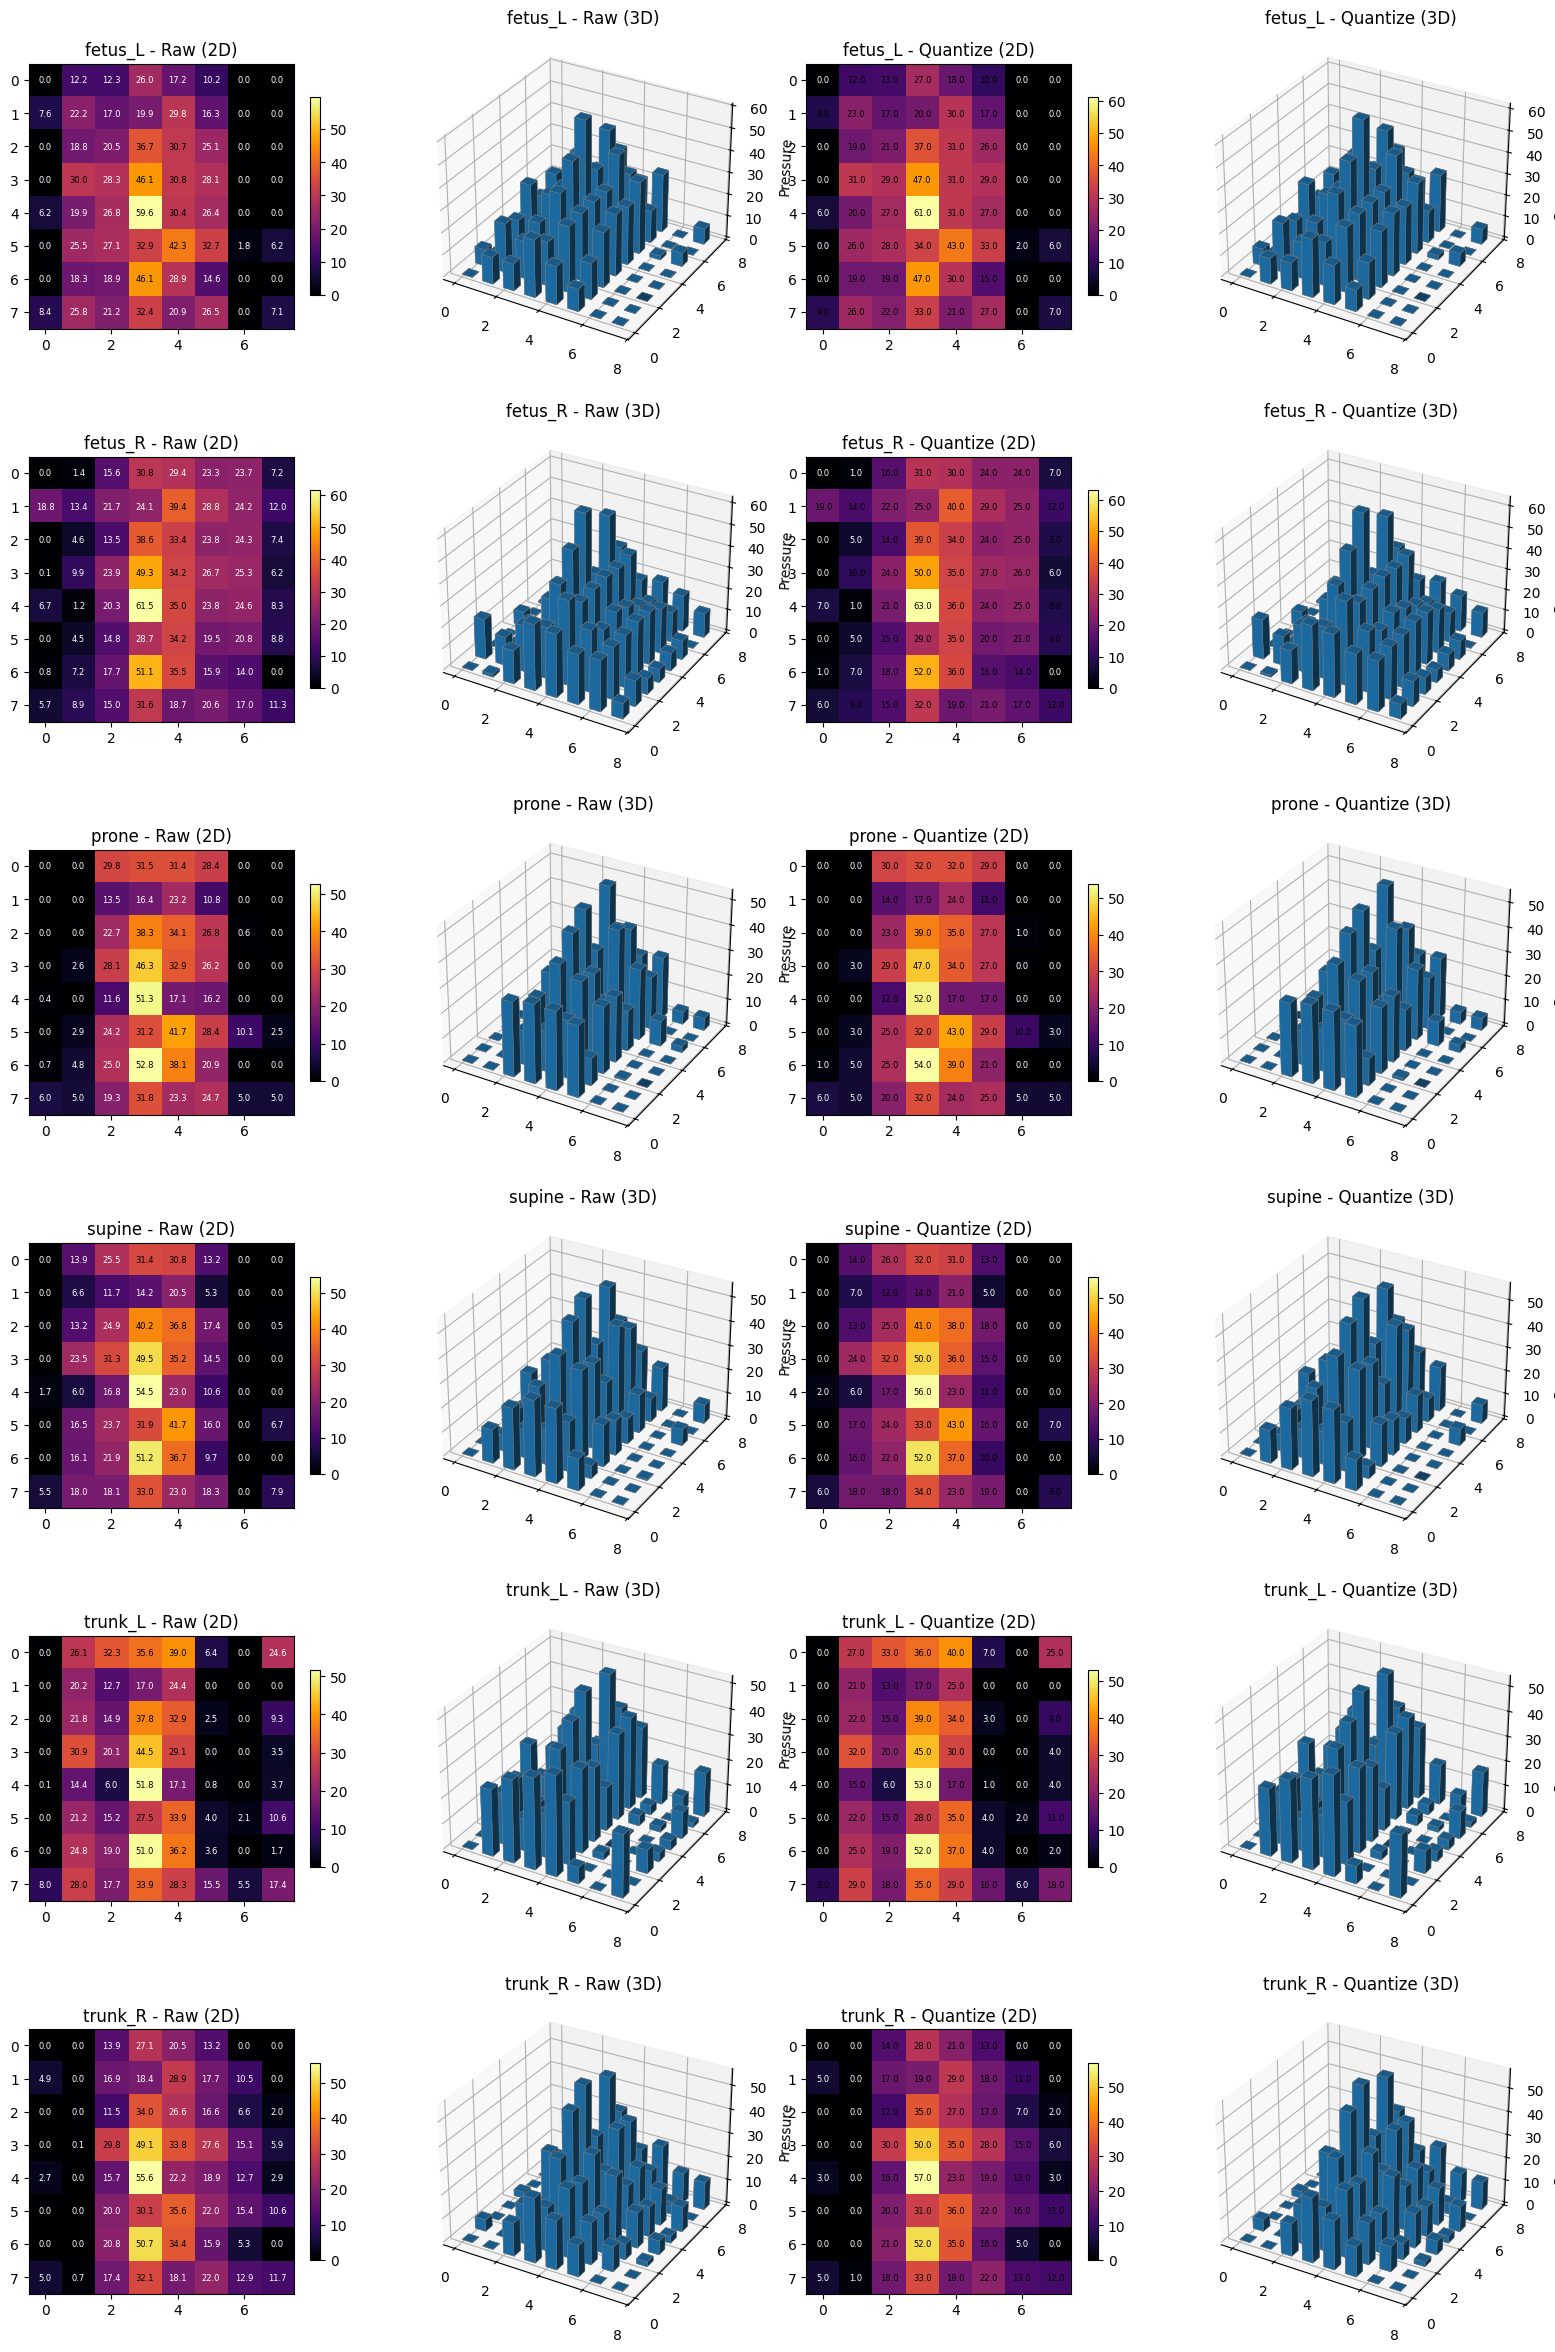

In [32]:
CMAP_STYLE = "inferno"

# Get one sample per unique label
unique_labels = np.unique(labels)
sample_indices = [np.where(labels == label)[0][0] for label in unique_labels]

# Create figure: 6 labels × 2 states (raw/normQuant) × 2 plots (2D/3D)
fig = plt.figure(figsize=(16, 24))

for i, idx in enumerate(sample_indices):
    label = labels[idx]
    raw = data[idx].reshape(8, 8)
    normQuant = data_q44[idx].reshape(8, 8)
    
    # Row position for this label
    row = i * 2
    
    # --- Raw: 2D heatmap ---
    ax1 = fig.add_subplot(6, 4, row * 2 + 1)
    im1 = ax1.imshow(raw, cmap=CMAP_STYLE)
    ax1.set_title(f"{label} - Raw (2D)")
    for r in range(8):
        for c in range(8):
            color = "black" if raw[r, c] > raw.max() / 2 else "white"
            ax1.text(c, r, f"{raw[r, c]:.1f}", ha="center", va="center", color=color, fontsize=6)
    plt.colorbar(im1, ax=ax1, shrink=0.6)
    
    # --- Raw: 3D surface ---
    ax2 = fig.add_subplot(6, 4, row * 2 + 2, projection="3d")
    
    X, Y = np.meshgrid(range(8), range(8))
    x_pos = X.ravel()
    y_pos = Y.ravel()
    z_pos = np.zeros_like(x_pos)  # Start bars at z=0
    # Bar dimensions
    dx = dy = 0.5 * np.ones_like(x_pos)
    dz = raw.ravel()
    ax2.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, cmap=CMAP_STYLE, edgecolor="gray", linewidth=0.3)
    
    ax2.set_title(f"{label} - Raw (3D)")
    ax2.set_zlabel("Pressure")
    
    # --- Quantize: 2D heatmap ---
    ax3 = fig.add_subplot(6, 4, row * 2 + 3)
    im3 = ax3.imshow(normQuant, cmap=CMAP_STYLE)
    ax3.set_title(f"{label} - Quantize (2D)")
    for r in range(8):
        for c in range(8):
            color = "black" if normQuant[r, c] > 7.5 else "white"
            ax3.text(c, r, f"{normQuant[r, c]:.1f}", ha="center", va="center", color=color, fontsize=6)
    plt.colorbar(im3, ax=ax3, shrink=0.6)
    
    # --- Quantize: 3D surface ---
    ax4 = fig.add_subplot(6, 4, row * 2 + 4, projection="3d")
    
    dz = normQuant.ravel()
    ax4.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, cmap=CMAP_STYLE, edgecolor="gray", linewidth=0.3)
    
    ax4.set_title(f"{label} - Quantize (3D)")
    ax4.set_zlabel("Pressure (Q4.4)")

plt.tight_layout(pad=3.0)
# plt.savefig("dataset/all_samples_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
# print(f"Saved: dataset/all_samples_comparison.png")

## Training, Validation and Test Data
Separate all raw, normalized and quantize datasets into (70/20/10)%

Saves in two formats:
- `.npz` for TensorFlow and PYNQ-Z2 (Python)
- `.hex` for Verilog testbenches ($readmemh)

In [33]:
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
RANDOM_STATE = 42

# Split indices with stratification (70/20/10)
# First split: 70% train, 30% temp
idx_train, idx_temp = train_test_split(
    range(len(labels)), test_size=0.30,
    random_state=RANDOM_STATE, stratify=labels
)

# Second split: 20% val, 10% test (from temp: 20/30 = 2/3)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=1/3,
    random_state=RANDOM_STATE, stratify=labels[idx_temp]
)

print(f"  Training:   {len(idx_train)} samples ({len(idx_train)/len(labels)*100:.0f}%)")
print(f"  Validation: {len(idx_val)} samples ({len(idx_val)/len(labels)*100:.0f}%)")
print(f"  Test:       {len(idx_test)} samples ({len(idx_test)/len(labels)*100:.0f}%)")

# Apply indices to all three data formats
datasets = {
    'raw': data,
    'normalized': data_normalized,
    'quantized': data_q44
}

splits = {
    'train': (idx_train, labels[idx_train]),
    'val': (idx_val, labels[idx_val]),
    'test': (idx_test, labels[idx_test])
}

# Create label mapping for Verilog
label_map = {label: idx for idx, label in enumerate(np.unique(labels))}

# Save all datasets
for data_name, data_array in datasets.items():
    for split_name, (indices, split_labels) in splits.items():
        split_data = data_array[indices]
        
        # Save NPZ for Python/PYNQ-Z2
        np.savez(f"output/{split_name}_{data_name}.npz",
                 data=split_data, labels=split_labels)
        
        # Save HEX for Verilog (only for quantized data)
        if data_name == 'quantized':
            with open(f"output/{split_name}_{data_name}.hex", "w") as f:
                f.write(f"// {split_name.upper()} Set - Q4.4 Fixed-Point\n")
                f.write(f"// Samples: {len(split_data)}\n")
                f.write("// Format: 64 hex values per sample (8x8, row-major)\n\n")
                for i, (sample, label) in enumerate(zip(split_data, split_labels)):
                    hex_vals = [f"{val:02x}" for val in sample]
                    label_idx = label_map[label]
                    f.write(f"// {label} (class {label_idx})\n")
                    f.write(" ".join(hex_vals) + "\n")

# print("\nSaved datasets:")
# for data_name in datasets.keys():
#     for split_name in splits.keys():
#         print(f"  dataset/{split_name}_{data_name}.npz")
#         if data_name == 'quantized':
#             print(f"  dataset/{split_name}_{data_name}.hex")

print(f"\nLabel mapping: {label_map}")

  Training:   134 samples (70%)
  Validation: 38 samples (20%)
  Test:       20 samples (10%)

Label mapping: {'fetus_L': 0, 'fetus_R': 1, 'prone': 2, 'supine': 3, 'trunk_L': 4, 'trunk_R': 5}
